In [84]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

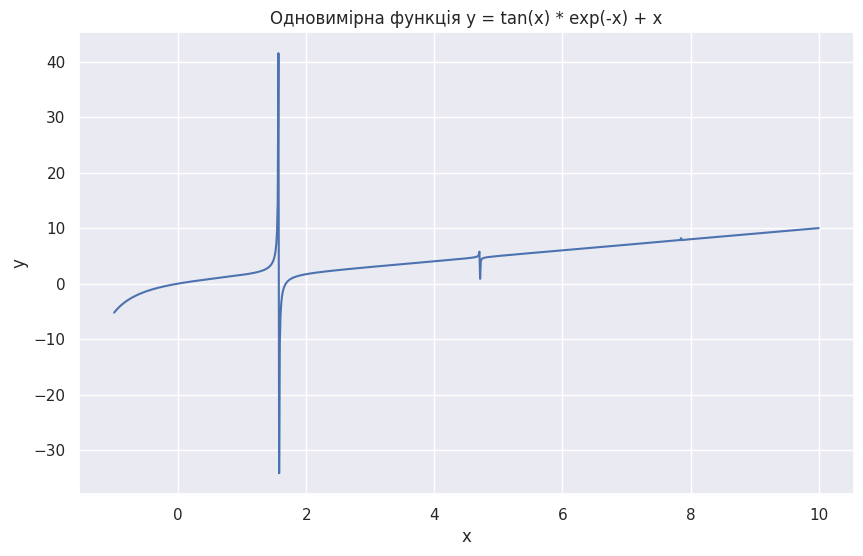

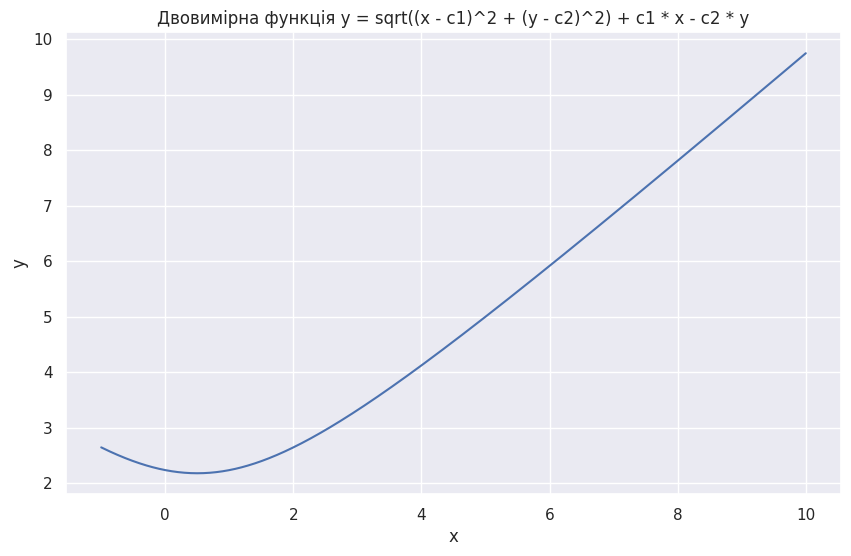

In [88]:
x = np.linspace(-1.0, 10.0, 1000)
y = np.tan(x) * np.exp(-x) + x

sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 6))
plt.plot(x, y)
plt.title('Одновимірна функція y = tan(x) * exp(-x) + x')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()

def f(x, y, c1, c2):
    return np.sqrt(((x - c1) ** 2 + (y - c2) ** 2) + c1 * x - c2 * y)

x_2 = np.linspace(-1.0, 10.0, 1000)
y_2 = f(x_2, 0, 1, 2)
sns.set_theme(style="darkgrid")

plt.figure(figsize=(10, 6))
plt.plot(x_2, y_2)
plt.title('Двовимірна функція y = sqrt((x - c1)^2 + (y - c2)^2) + c1 * x - c2 * y')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()



Мінімум функції знаходиться приблизно в точці x = -1.000000, y = -5.233468
Максимум функції знаходиться приблизно в точці x = -0.000000, y = -0.000001


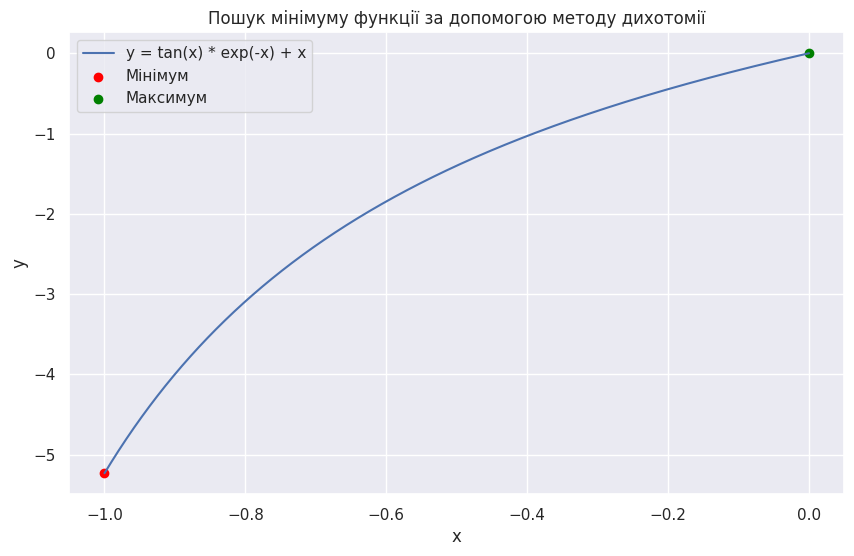

In [95]:
def func(x):
    return np.tan(x) * np.exp(-x) + x

def dichotomy_min(func, a, b, tol=1e-6, max_iter=1000):
    if a >= b:
        raise ValueError("Початок інтервалу a має бути меншим за кінець b.")
    
    for _ in range(max_iter):
        x1 = a + (b - a) / 3
        x2 = a + 2 * (b - a) / 3
        
        f_x1 = func(x1)
        f_x2 = func(x2)
        
        if f_x1 < f_x2:
            b = x2  
        else:
            a = x1  
        
        if abs(b - a) < tol:
            break
    else:
        print("Досягнуто максимальну кількість ітерацій.")
    
    return (a + b) / 2

def dichotomy_max(func, a, b, tol=1e-6, max_iter=1000):
    if a >= b:
        raise ValueError("Початок інтервалу a має бути меншим за кінець b.")
    
    for _ in range(max_iter):
        x1 = a + (b - a) / 3
        x2 = a + 2 * (b - a) / 3
        
        f_x1 = func(x1)
        f_x2 = func(x2)
        
        if f_x1 > f_x2:
            b = x2  
        else:
            a = x1  
        
        if abs(b - a) < tol:
            break
    else:
        print("Досягнуто максимальну кількість ітерацій.")
    
    return (a + b) / 2

a = -1.0  
b = 0.0   
tol = 1e-6  

x_min = dichotomy_min(func, a, b, tol)
y_min = func(x_min)

x_max = dichotomy_max(func, a, b, tol)
y_max = func(x_max)

print(f"Мінімум функції знаходиться приблизно в точці x = {x_min:.6f}, y = {y_min:.6f}")
print(f"Максимум функції знаходиться приблизно в точці x = {x_max:.6f}, y = {y_max:.6f}")

x = np.linspace(-1.0, 0.0, 1000)
y = func(x)

sns.set_theme(style="darkgrid")
plt.figure(figsize=(10, 6))
plt.plot(x, y, label='y = tan(x) * exp(-x) + x')
plt.scatter(x_min, y_min, color='red', label='Мінімум')
plt.scatter(x_max, y_max, color='green', label='Максимум')
plt.title('Пошук мінімуму функції за допомогою методу дихотомії')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

Мінімум функції знаходиться приблизно в точці x = -1.000000, y = -5.233473


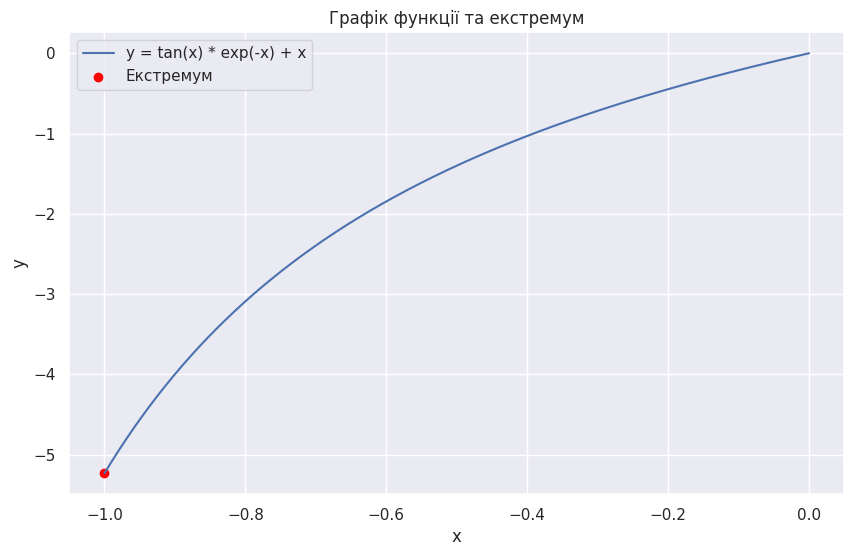

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def func(x):
    if x < -1 or x > 0:
        return np.inf 
    return np.tan(x) * np.exp(-x) + x

def func2(x):
    return np.tan(x) * np.exp(-x) + x

def gradient(x):
    if x < -1:
        return -1  
    elif x > 0:
        return 1   
    else:
        cos_x = np.cos(x)
        exp_neg_x = np.exp(-x)
        return (exp_neg_x / cos_x**2) - (np.tan(x) * exp_neg_x) + 1

def fast_descent_min(f, grad, x0, h=0.01, epsilon=1e-6, max_iter=1000):
    x = x0
    g = grad(x)
    i = np.sign(g)

    for _ in range(max_iter):
        x_new = x - h * g
        if x_new < -1:
            x_new = -1
        elif x_new > 0:
            x_new = 0
        g_new = grad(x_new)

        if np.isnan(g_new) or np.isinf(g_new):
            print("Зустріно nan або inf. Зупинка.")
            return x_new

        if abs(g_new) < epsilon or (x_new <= -1 and g_new > 0) or (x_new >= 0 and g_new < 0):
            return x_new

        i1 = np.sign(g_new)
        if i1 != i:
            h = h / 2
        else:
            h = 1.6 * h 

        x = x_new
        g = g_new
        i = i1

    print("Досягнуто максимальну кількість ітерацій.")
    return x

def fast_descent_max(f, grad, x0, h=0.01, epsilon=1e-6, max_iter=1000):
    x = x0
    g = grad(x)
    i = np.sign(g)

    for _ in range(max_iter):
        x_new = x + h * g
        if x_new < -1:
            x_new = -1
        elif x_new > 0:
            x_new = 0
        g_new = grad(x_new)

        if np.isnan(g_new) or np.isinf(g_new):
            print("Зустріно nan або inf. Зупинка.")
            return x_new

        if abs(g_new) < epsilon or (x_new <= -1 and g_new < 0) or (x_new >= 0 and g_new > 0):
            return x_new

        i1 = np.sign(g_new)
        if i1 != i:
            h = h / 2
        else:
            h = 1.6 * h 

        x = x_new
        g = g_new
        i = i1

    print("Досягнуто максимальну кількість ітерацій.")
    return x

x0 = -0.5  
x_min = fast_descent_min(func, gradient, x0)
y_min = func(x_min)
print(f"Мінімум функції знаходиться приблизно в точці x = {x_min:.6f}, y = {y_min:.6f}")

x_values = np.linspace(-1, 0, 1000)
y_values = func2(x_values)

plt.figure(figsize=(10, 6))
plt.plot(x_values, y_values, label='y = tan(x) * exp(-x) + x')
plt.scatter(x_min, y_min, color='red', label='Екстремум')
plt.title('Графік функції та екстремум')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()